In [54]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.metrics import silhouette_score

In [55]:
df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [56]:
df.shape

(200, 5)

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [58]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


### Missing Values

The dataset contains no missing values, so no imputation was required.

In [59]:
df.drop("CustomerID", axis=1, inplace=True)

In [60]:
df['Gender'] = df['Gender'].map({
    'Male':1,
    'Female':0
})

## Feature Scaling

K-Means clustering uses distance to group similar customers.
Since features like Annual Income and Spending Score have different ranges,
we standardize the data using StandardScaler so that each feature contributes equally.

In [61]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [62]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

In [64]:
wcss=[]

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(scaled_data)

    wcss.append(kmeans.inertia_)

In [65]:
scaled_data[:5]

array([[ 1.12815215, -1.42456879, -1.73899919, -0.43480148],
       [ 1.12815215, -1.28103541, -1.73899919,  1.19570407],
       [-0.88640526, -1.3528021 , -1.70082976, -1.71591298],
       [-0.88640526, -1.13750203, -1.70082976,  1.04041783],
       [-0.88640526, -0.56336851, -1.66266033, -0.39597992]])

In [66]:
wcss = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(scaled_data)
    wcss.append(model.inertia_)

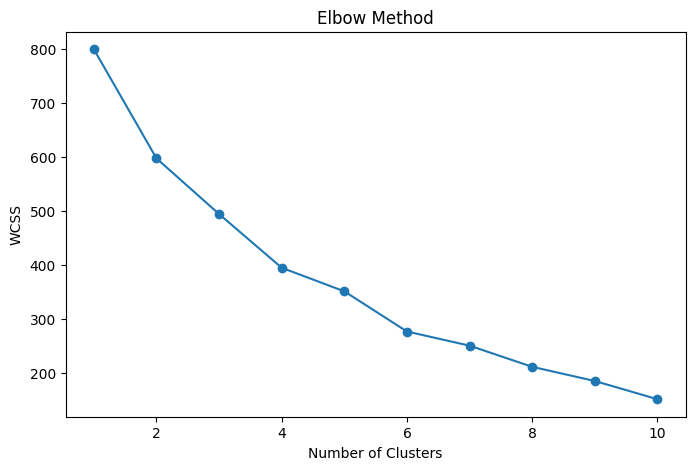

In [67]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

## Elbow Method

The Elbow Method was used to determine the optimal number of clusters.

From the graph, the elbow appears at **k = 4**. Therefore, the K-Means model is trained using **4 clusters**.

In [68]:
kmeans = KMeans(n_clusters=4, random_state=42)

clusters = kmeans.fit_predict(scaled_data)

In [69]:
df["Cluster"] = clusters

In [70]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,19,15,39,2
1,1,21,15,81,2
2,0,20,16,6,3
3,0,23,16,77,3
4,0,31,17,40,3


In [71]:
cluster_profile = df.groupby("Cluster").mean()

cluster_profile

,Gender,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,0.433333,54.700000,46.900000,39.933333
1,0.588235,41.264706,88.500000,16.764706
2,1.000000,28.690476,60.904762,70.238095
3,0.000000,29.375000,58.296875,64.437500


## Cluster Analysis

### Cluster 0 – Mature Average Spenders
- Average Age: ~55 years
- Moderate Annual Income
- Moderate Spending Score

**Business Strategy:**
- Offer loyalty rewards.
- Promote products for mature customers.
- Focus on customer retention.

---

### Cluster 1 – High Income, Low Spending Customers
- High Annual Income
- Low Spending Score

**Business Strategy:**
- Encourage purchases through personalized offers.
- Recommend premium products.
- Use exclusive membership programs.

---

### Cluster 2 – Young Male High Spenders
- Mostly Male customers
- Young age group
- High Spending Score

**Business Strategy:**
- Promote trendy and premium products.
- Use digital marketing and seasonal offers.
- Encourage repeat purchases.

---

### Cluster 3 – Young Female High Spenders
- Mostly Female customers
- Young age group
- High Spending Score

**Business Strategy:**
- Advertise fashion and lifestyle products.
- Provide personalized recommendations.
- Introduce loyalty programs and festive discounts.

In [72]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

In [73]:
pca_df = pd.DataFrame(
    pca_data,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = clusters

pca_df.head()

,PC1,PC2,Cluster
0,-0.406383,-0.520714,2
1,-1.427673,-0.367310,2
2,0.050761,-1.894068,3
3,-1.694513,-1.631908,3
4,-0.313108,-1.810483,3


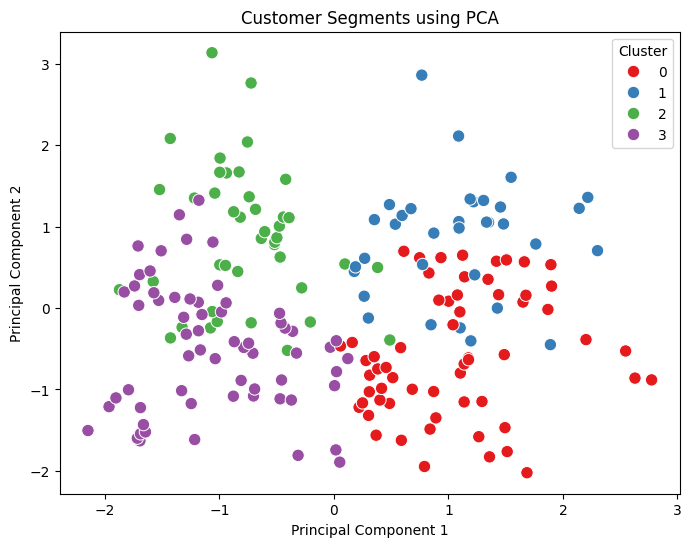

In [74]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1",
    s=80
)

plt.title("Customer Segments using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [75]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Explained Variance:", sum(pca.explained_variance_ratio_))

Explained Variance Ratio: [0.33690046 0.26230645]
Total Explained Variance: 0.5992069019819846


## Conclusion

This project successfully applied K-Means Clustering to segment mall customers into four meaningful groups.

The Elbow Method was used to determine the optimal number of clusters, and PCA reduced the dataset to two dimensions for visualization.

The identified customer segments provide useful business insights that can help organizations design targeted marketing campaigns, improve customer engagement, and increase sales through personalized strategies.